In [1]:
#A Century of Top Songs

#The 'top-song-durations.csv' file contains information about the number-one hit song for each year from 1923 to 2023. Load the data into python and take a look.


In [2]:
#Import pandas.
import pandas as pd

#Load the top song duration data.
df = pd.read_csv('/kaggle/input/datasets/mamdouhsamir/top-song-durations/top-song-durations.csv')

#Display the first 5 rows.
df.head(5)


,year,artist,title,duration
0,2023,Morgan Wallen,Last Night,00:02:43
1,2022,Glass Animals,Heat Waves,00:03:58
2,2021,Dua Lipa,Levitating,00:03:23
3,2020,The Weeknd,Blinding Lights,00:03:20
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37


In [3]:
#Find the shortest song in the dataset.

df.query('duration == duration.min()')


,year,artist,title,duration
95,1928,Al Jolson,Sonny Boy,00:01:55


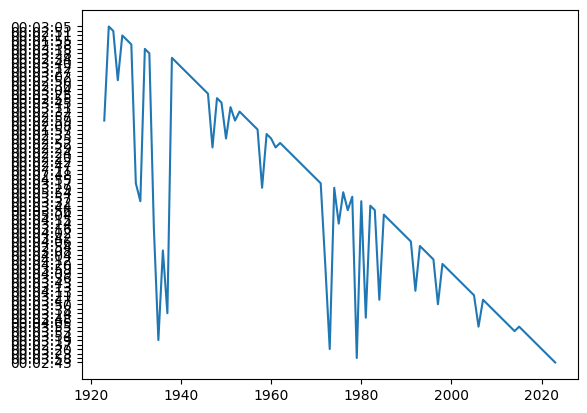

In [4]:
#One might expect the following code to generate a plot of the duration over the years. Run the code to see what happens.

import matplotlib.pyplot as plt
plt.plot(df['year'], df['duration'])

#Error: TypeError: plt.plot() requires the y-axis to be numeric.[3]

#Oops... It seems that the data on the y-axis is not numeric.
#We can get a listing of the data types for each column using the info( )method.




In [5]:
#Activity Goal:List basic information for each column.

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   year      101 non-null    int64 
 1   artist    101 non-null    object
 2   title     101 non-null    object
 3   duration  101 non-null    object
dtypes: int64(1), object(3)
memory usage: 3.3+ KB


In [6]:
#Parsing the duration
#In order to graph our data, we need to convert the duration strings into numbers. As with most coding goals, there are multiple ways we could pull this off. The following is one approach.

#We can first use the str.split() method to split each duration string (e.g. "00:01:55"). We'll split using the ":" character to get separate substrings for hours, minutes, and seconds.

#Activity Goals:
#Split the duration values on the ':' character.
#Expand the result into new columns.
#Assign the result to a new dataframe called split_duration.
#Show the first 5 rows of split_duration.

split_duration = df['duration'].str.split(':', expand=True)
split_duration.head(5)



,0,1,2
0,00,02,43
1,00,03,58
2,00,03,23
3,00,03,20
4,00,02,37


In [7]:
#Let's now convert all these string values to integers using the astype( ) method.

#Activity Goals:

#Convert all values in split_duration to integers.
split_duration = split_duration.astype('int')

#Display the first 5 rows.
split_duration.head(5)




,0,1,2
0,0,2,43
1,0,3,58
2,0,3,23
3,0,3,20
4,0,2,37


In [8]:
#Naming the columns
#Now let's bring these new numeric columns back into our main dataframe. We also want give the columns better names than 0, 1 and 2.

#We can use 'h', 'm' and 's' as short names for hours, minutes and seconds.

#Add 'h', 'm', and 's' columns to our main dataframe.
df[['h', 'm', 's']] = split_duration

#Show the first 5 rows.
df.head(5)





,year,artist,title,duration,h,m,s
0,2023,Morgan Wallen,Last Night,00:02:43,0,2,43
1,2022,Glass Animals,Heat Waves,00:03:58,0,3,58
2,2021,Dua Lipa,Levitating,00:03:23,0,3,23
3,2020,The Weeknd,Blinding Lights,00:03:20,0,3,20
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37,0,2,37


In [9]:
#Calculating total seconds
#Now that we have 'h', 'm' and 's' columns, we can use an eval( ) to calculate the total seconds.
#Since there are 3600 seconds in an hour, we can use the formula:
#total_seconds = h*3600 + m*60 + s

#Calculate the total seconds for each song.
#Assign the result to a new column called 'total_seconds'.
df['total_seconds'] = df.eval('h*3600 + m*60 + s')

#Display the first 5 rows.
df.head(5)







,year,artist,title,duration,h,m,s,total_seconds
0,2023,Morgan Wallen,Last Night,00:02:43,0,2,43,163
1,2022,Glass Animals,Heat Waves,00:03:58,0,3,58,238
2,2021,Dua Lipa,Levitating,00:03:23,0,3,23,203
3,2020,The Weeknd,Blinding Lights,00:03:20,0,3,20,200
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37,0,2,37,157


Text(0, 0.5, 'Duration (Seconds)')

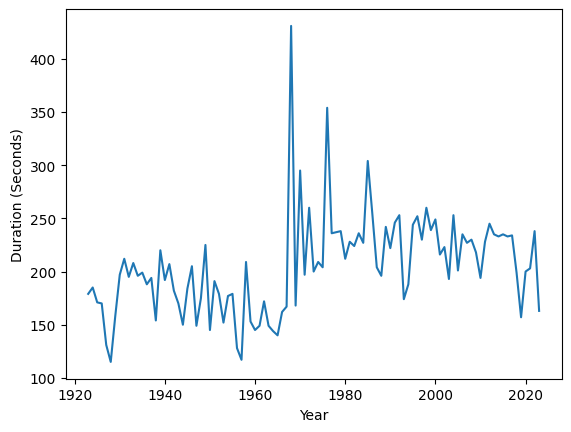

In [10]:
#Plotting top-hit song durations
#Let's visualize how the durations of top-hit songs changed over the years.

#Plot the total_seconds vs year.
plt.plot(df['year'],df['total_seconds'])

#Label the axes.
plt.xlabel('Year')
plt.ylabel('Duration (Seconds)')


In [11]:
#The longest top hit
#What is that longest top-hit song that forms a sharp peak on the graph? It appears to be about twice as long as any top-hit song that came before it. Let's find out.

#Find the longest song in the dataset.
df.query('total_seconds == total_seconds.max()')



,year,artist,title,duration,h,m,s,total_seconds
55,1968,The Beatles,Hey Jude,00:07:11,0,7,11,431
